In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [7]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)

# Phân tích lỗi trên tập validation

In [3]:
VAL_DF = "../../data/gold/val.csv"
TEST_DF = "../../data/gold/test.csv"
VAL_PRED = "../../data/error_analysis/qwen-instruct-v1/val_predictions.csv"
TEST_PRED = "../../data/error_analysis/qwen-instruct-v1/test_predictions.csv"

In [4]:
val_df = pd.read_csv(VAL_DF)
test_df = pd.read_csv(TEST_DF)
val_pred = pd.read_csv(VAL_PRED)
test_pred = pd.read_csv(TEST_PRED)

In [6]:
ASPECTS = [
    "graphics", "matchmaking", "store & microtransactions",
    "technical_issue", "mechanics", "developer_support",
    "event", "community", "hero_design", "difficulty"
]
LABELS = {0: "not mention", 1: "neutral/pos", 2: "negative"}

In [5]:
val_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   review                          519 non-null    object
 1   graphics_true                   519 non-null    int64 
 2   graphics_pred                   519 non-null    int64 
 3   matchmaking_true                519 non-null    int64 
 4   matchmaking_pred                519 non-null    int64 
 5   store & microtransactions_true  519 non-null    int64 
 6   store & microtransactions_pred  519 non-null    int64 
 7   technical_issue_true            519 non-null    int64 
 8   technical_issue_pred            519 non-null    int64 
 9   mechanics_true                  519 non-null    int64 
 10  mechanics_pred                  519 non-null    int64 
 11  developer_support_true          519 non-null    int64 
 12  developer_support_pred          519 non-null    in

## Label distribution explaining

## Per-aspect error rate

**So sánh tỉ lệ lỗi theo từng khía cạnh để xác định điểm yếu của model**

In [12]:
def per_aspect_metrics(df, aspects):
    records = []
    for asp in aspects:
        y_true = df[f"{asp}_true"]
        y_pred = df[f"{asp}_pred"]
        err_rate = (y_true != y_pred).mean()
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        f1_per = f1_score(y_true, y_pred, average=None,
                          labels=[0,1,2], zero_division=0)
        records.append({
            "aspect": asp,
            "error_rate": round(err_rate, 4),
            "macro_f1": round(macro_f1, 4),
            "f1_label0": round(f1_per[0], 4),
            "f1_label1": round(f1_per[1], 4),
            "f1_label2": round(f1_per[2], 4),
        })
    return pd.DataFrame(records).sort_values("error_rate", ascending=False)

aspect_metrics = per_aspect_metrics(test_pred, ASPECTS)
print(aspect_metrics.to_string(index=False))

                   aspect  error_rate  macro_f1  f1_label0  f1_label1  f1_label2
        developer_support      0.1368    0.7332     0.9333     0.5672     0.6990
                mechanics      0.1156    0.6256     0.9280     0.1667     0.7823
          technical_issue      0.0829    0.9446     0.9181     1.0000     0.9159
              matchmaking      0.0713    0.6106     0.9525     0.0000     0.8792
                community      0.0443    0.6314     0.9690     0.0000     0.9252
store & microtransactions      0.0405    0.4787     0.9790     0.0000     0.4571
                 graphics      0.0308    0.6210     0.9880     0.5000     0.3750
              hero_design      0.0289    0.6422     0.9880     0.4000     0.5385
               difficulty      0.0212    0.4964     0.9892     0.0000     0.5000
                    event      0.0135    0.5910     0.9951     0.3333     0.4444


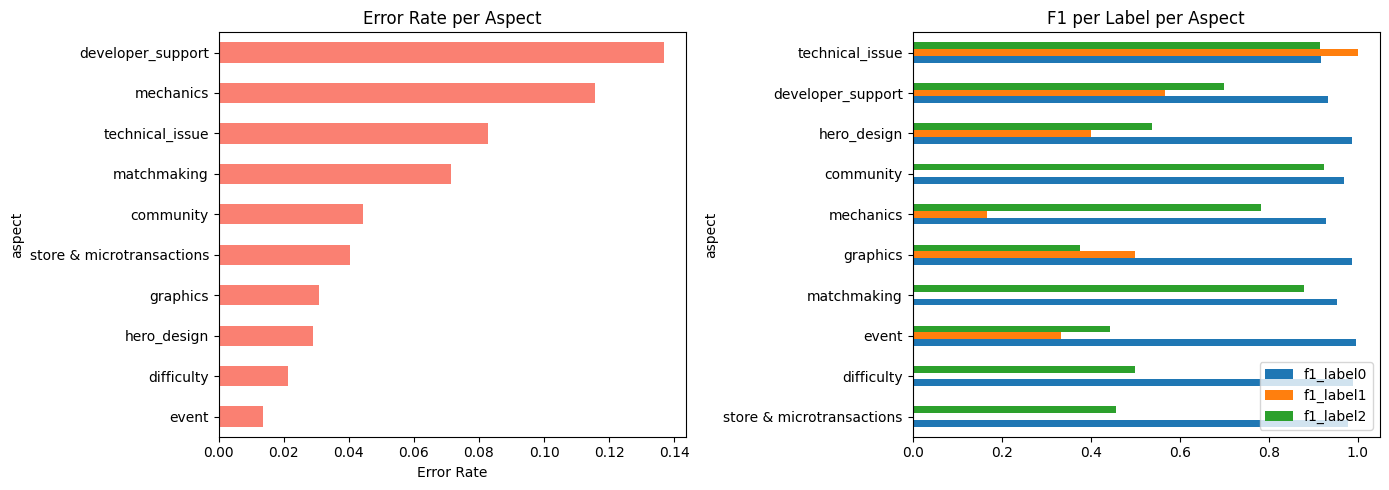

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
aspect_metrics.sort_values("error_rate").plot.barh(
    x="aspect", y="error_rate", ax=axes[0], color="salmon", legend=False
)
axes[0].set_title("Error Rate per Aspect")
axes[0].set_xlabel("Error Rate")

aspect_metrics.sort_values("macro_f1").plot.barh(
    x="aspect", y=["f1_label0","f1_label1","f1_label2"],
    ax=axes[1], legend=True
)
axes[1].set_title("F1 per Label per Aspect")
plt.tight_layout()
plt.savefig("per_aspect_metrics.png", dpi=150)

-  Label imbalance là nguyên nhân gốc rễ. Label 1 gần như không xuất hiện ở nhiều aspects trong tập dữ liệu, khiến model không học được ranh giới giữa "không đề cập" và "đề cập tích cực". Đây là hạn chế của dữ liệu, không hoàn toàn do model.

- Model hoạt động tốt khi ngôn ngữ đặc trưng. technical_issue là bằng chứng rõ nhất: từ vựng domain-specific giúp model nhận diện tốt cả 3 nhãn. Các aspect trừu tượng hơn như store, event cần thêm dữ liệu hoặc domain-specific vocabulary.

- Qwen2.5-1.5B với QLoRA đủ năng lực học pattern tiêu cực (label 2 tốt ở nhiều aspects), nhưng bị giới hạn bởi kích thước model khi xử lý ngữ cảnh mơ hồ và code-switching tiếng Việt–Anh đặc trưng của bình luận game.

- Giải thích lý do:

| Aspect | Error Rate | Macro F1 | Vấn đề chính | Lý do domain |
|---|---|---|---|---|
| `technical_issue` | 8.29% | 0.9446 | Tốt nhất toàn bộ, label 1 F1 = 1.0 | Từ khóa tiêu cực rất đặc trưng: "lag", "giật", "bug", "crash" — dễ học |
| `developer_support` | 13.68% | 0.7332 | Error rate cao nhưng F1 tốt nhất nhóm còn lại | Nhiều mẫu có nhãn 1 và 2 hơn → sai nhiều hơn nhưng học được nhiều hơn |
| `mechanics` | 11.56% | 0.6256 | Label 1 F1 = 0.167, label 2 tốt (0.782) | "Gameplay ok" vs "cơ chế lỗi" — diễn đạt trung tính rất đa dạng, khó phân biệt 0 và 1 |
| `matchmaking` | 7.13% | 0.6106 | Label 1 F1 = 0.000, label 2 tốt (0.879) | Người chơi gần như chỉ phàn nàn matchmaking, cực hiếm khen → model không thấy nhãn 1 |
| `community` | 4.43% | 0.6314 | Label 1 F1 = 0.000, label 2 tốt (0.925) | Tương tự matchmaking — bình luận về cộng đồng thường chỉ là tiêu cực (toxic, troll) |
| `hero_design` | 2.89% | 0.6422 | Label 1 F1 = 0.400, label 2 trung bình (0.539) | "Skin đẹp" vs "hero xấu/yếu" — ranh giới tích cực/tiêu cực phụ thuộc ngữ cảnh meta game |
| `graphics` | 3.08% | 0.6210 | Label 1 F1 = 0.500, label 2 yếu (0.375) | Đánh giá đồ họa thường ngắn gọn, mơ hồ: "đẹp" / "ổn" khó phân biệt với không đề cập |
| `store & microtransactions` | 4.05% | 0.4787 | Label 1 F1 = 0.000, label 2 yếu (0.457) | "Chặt chém", "đắt" vs "skin đẹp quá" — ranh giới nhãn 1 và 2 rất mờ; label 1 cực hiếm |
| `event` | 1.35% | 0.5910 | Accuracy paradox — error rate thấp nhất nhưng F1 thấp | Event ít được nhắc đến → model predict nhãn 0 gần hết, đúng nhiều nhưng không học được nhãn 1/2 |
| `difficulty` | 2.12% | 0.4964 | Accuracy paradox — label 1 F1 = 0.000 | "Khó" có thể là khen hoặc chê tùy ngữ cảnh; model không phân biệt được → thiên về nhãn 0 |

In [42]:
def label_distribution_analysis(df, aspects, aspect_metrics):
    records = []
    for asp in aspects:
        col = df[f"{asp}_true"]
        total = len(col)
        c0 = (col == 0).sum()
        c1 = (col == 1).sum()
        c2 = (col == 2).sum()
        records.append({
            "aspect":      asp,
            "n_label0": int(c0), "pct_label0": round(c0/total*100, 1),
            "n_label1": int(c1), "pct_label1": round(c1/total*100, 1),
            "n_label2": int(c2), "pct_label2": round(c2/total*100, 1),
        })

    dist_df = (pd.DataFrame(records)
                 .sort_values("pct_label1", ascending=True)
                 .reset_index(drop=True))

    print(dist_df[["aspect","n_label0","pct_label0",
                   "n_label1","pct_label1",
                   "n_label2","pct_label2"]].to_string(index=False))

    # ── Visualization ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: chỉ vẽ label 1 và 2 — zoom vào vùng thiểu số
    # Dùng số lượng tuyệt đối thay vì % để rõ hơn
    y_pos = range(len(dist_df))
    bar_h = 0.35

    bars1 = axes[0].barh(
        [y + bar_h/2 for y in y_pos],
        dist_df["n_label1"],
        height=bar_h, color="#EF9F27", label="Label 1 (neutral/pos)"
    )
    bars2 = axes[0].barh(
        [y - bar_h/2 for y in y_pos],
        dist_df["n_label2"],
        height=bar_h, color="#E24B4A", label="Label 2 (negative)"
    )

    # Gán nhãn số lên bar
    for bar in bars1:
        w = bar.get_width()
        if w > 0:
            axes[0].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                         str(int(w)), va='center', fontsize=9,
                         color="#854F0B", fontweight='bold')
    for bar in bars2:
        w = bar.get_width()
        if w > 0:
            axes[0].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                         str(int(w)), va='center', fontsize=9,
                         color="#A32D2D", fontweight='bold')

    axes[0].set_yticks(list(y_pos))
    axes[0].set_yticklabels(dist_df["aspect"], fontsize=10)
    axes[0].set_xlabel("Số lượng mẫu", fontsize=11)
    axes[0].set_title(
        "Số mẫu label 1 và label 2 theo aspect\n"
        "(label 0 chiếm 70–98%, không vẽ để dễ đọc)",
        fontsize=11
    )
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', alpha=0.2)

    # Plot 2: scatter pct_label1 vs f1_label1
    merged = dist_df.merge(
        aspect_metrics[["aspect", "f1_label1", "f1_label2"]], on="aspect"
    )
    scatter_colors = [
        "#E24B4A" if p < 1 else "#EF9F27" if p < 5 else "#639922"
        for p in merged["pct_label1"]
    ]
    axes[1].scatter(
        merged["n_label1"], merged["f1_label1"],
        c=scatter_colors, s=120, zorder=5
    )
    for _, row in merged.iterrows():
        axes[1].annotate(
            row["aspect"],
            (row["n_label1"], row["f1_label1"]),
            textcoords="offset points", xytext=(6, 4),
            fontsize=8, color="gray"
        )
    axes[1].set_xlabel("Số mẫu label 1 trong tập test", fontsize=11)
    axes[1].set_ylabel("F1 Label 1", fontsize=11)
    axes[1].set_title(
        "Số mẫu label 1 → F1 label 1\n(ít mẫu = F1 thấp)",
        fontsize=11
    )
    axes[1].axvline(x=5, color="#E24B4A", linestyle="--",
                    linewidth=1, alpha=0.7, label="Ngưỡng 5 mẫu")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.2)

    # Chú thích label 0
    note = "\n".join([
        f"{r['aspect']:28s}: {r['n_label0']:3d} mẫu ({r['pct_label0']:.1f}%)"
        for _, r in dist_df.iterrows()
    ])
    print(f"\n── Label 0 (not mention) — chiếm đa số ──\n{note}")

    plt.suptitle(
        "Label Distribution Analysis — Nguồn gốc của label imbalance",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    return dist_df

                   aspect  n_label0  pct_label0  n_label1  pct_label1  n_label2  pct_label2
          technical_issue       277        53.4         1         0.2       241        46.4
                community       369        71.1         1         0.2       149        28.7
               difficulty       505        97.3         1         0.2        13         2.5
store & microtransactions       498        96.0         2         0.4        19         3.7
                    event       511        98.5         3         0.6         5         1.0
              matchmaking       371        71.5         3         0.6       145        27.9
              hero_design       502        96.7         6         1.2        11         2.1
                 graphics       502        96.7         8         1.5         9         1.7
                mechanics       400        77.1        11         2.1       108        20.8
        developer_support       387        74.6        33         6.4        99 

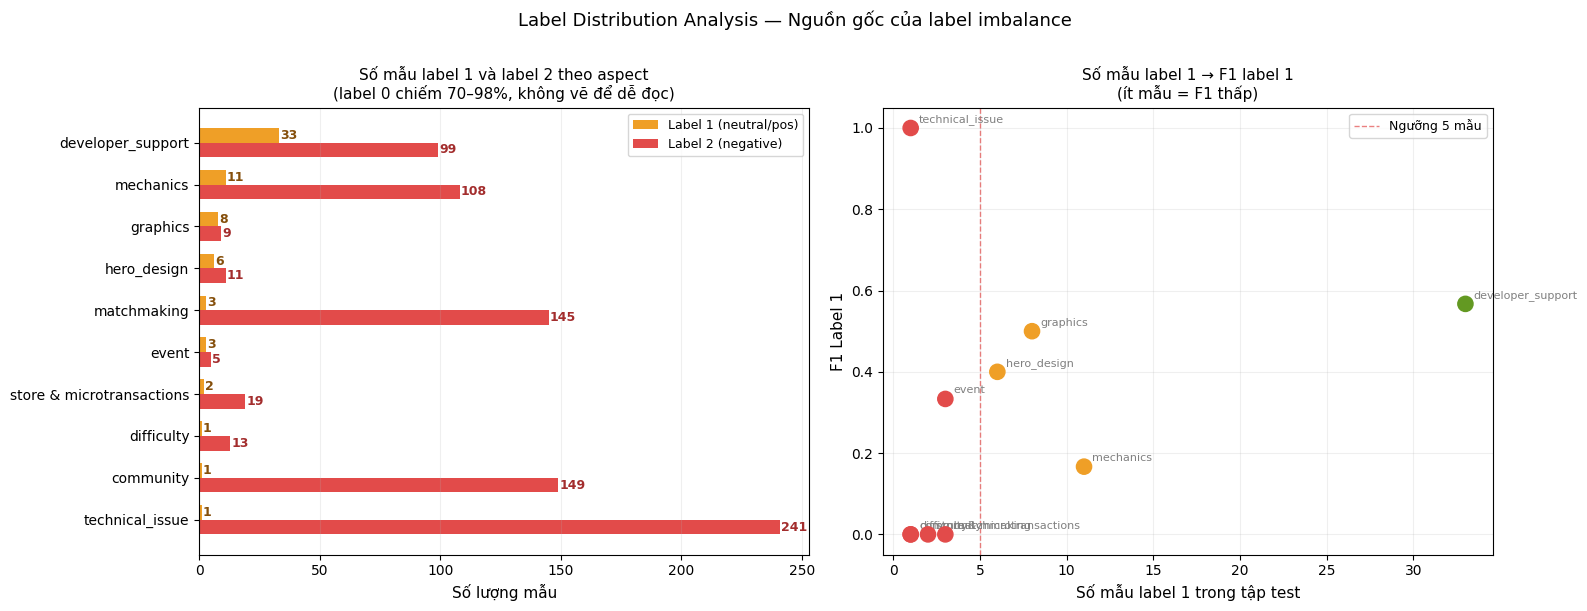

In [43]:
dist_df = label_distribution_analysis(test_pred, ASPECTS, aspect_metrics)

- 8/10 aspects đều dưới 2% label 1: F1=0 ở label 1 là do data quá sparse, không phải do model yếu.

> **Lưu ý về phân bố nhãn:** Tập dữ liệu được thu thập có chủ đích từ các đánh
> giá 1–3 sao nhằm tập trung phân tích bất mãn của người chơi. Do đó label 1
> (neutral/positive) xuất hiện với tần suất thấp (0.2%–6.4%) là **đặc tính tự
> nhiên của tập dữ liệu**, không phải lỗi gán nhãn. Label 1 trong ngữ cảnh này
> thường phản ánh đánh giá hỗn hợp: không hài lòng tổng thể nhưng vẫn ghi nhận
> một số điểm tích cực.

In [41]:
for asp in ASPECTS:
    counts = test_pred[f"{asp}_true"].value_counts().sort_index()
    print(f"{asp:30s} | 0:{counts.get(0,0):4d} | 1:{counts.get(1,0):4d} | 2:{counts.get(2,0):4d}")

graphics                       | 0: 502 | 1:   8 | 2:   9
matchmaking                    | 0: 371 | 1:   3 | 2: 145
store & microtransactions      | 0: 498 | 1:   2 | 2:  19
technical_issue                | 0: 277 | 1:   1 | 2: 241
mechanics                      | 0: 400 | 1:  11 | 2: 108
developer_support              | 0: 387 | 1:  33 | 2:  99
event                          | 0: 511 | 1:   3 | 2:   5
community                      | 0: 369 | 1:   1 | 2: 149
hero_design                    | 0: 502 | 1:   6 | 2:  11
difficulty                     | 0: 505 | 1:   1 | 2:  13


## Confusion Matrix per Aspect

**Phân tích nhầm lẫn giữa 3 nhãn (0/1/2), đặc biệt label imbalance (do lớp 0 chiếm đa số)**

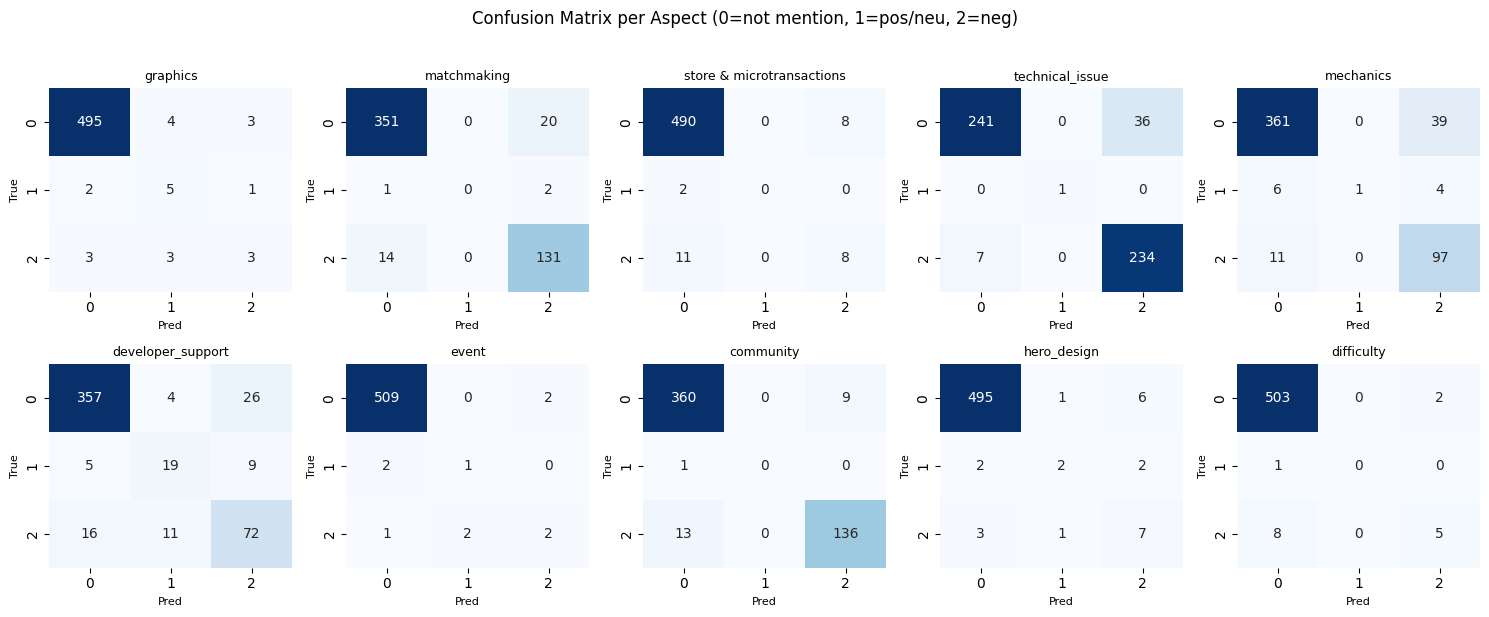

In [14]:
def plot_confusion_matrices(df, aspects, ncols=5):
    nrows = (len(aspects) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    axes = axes.flatten()
    for i, asp in enumerate(aspects):
        cm = confusion_matrix(df[f"{asp}_true"], df[f"{asp}_pred"],
                              labels=[0,1,2])
        sns.heatmap(cm, annot=True, fmt="d", ax=axes[i],
                    xticklabels=["0","1","2"],
                    yticklabels=["0","1","2"],
                    cmap="Blues", cbar=False)
        axes[i].set_title(asp, fontsize=9)
        axes[i].set_xlabel("Pred", fontsize=8)
        axes[i].set_ylabel("True", fontsize=8)
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.suptitle("Confusion Matrix per Aspect (0=not mention, 1=pos/neu, 2=neg)",
                 y=1.02)
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")

plot_confusion_matrices(test_pred, ASPECTS)

## Error Pattern by Label Transition

**Error Pattern by Label Transition - Model dễ nhầm cặp nào: 0→1 (false activation), 0→2 (false negative detection), hay 1↔2 (sentiment flip).**



── Label Transition Analysis ──
 true_label  pred_label transition  count                     type
          0           2        0→2    151 False Activation (0→1/2)
          2           0        2→0     87    False Silence (1/2→0)
          1           0        1→0     22    False Silence (1/2→0)
          1           2        1→2     18     Sentiment Flip (1↔2)
          2           1        2→1     17     Sentiment Flip (1↔2)
          0           1        0→1      9 False Activation (0→1/2)


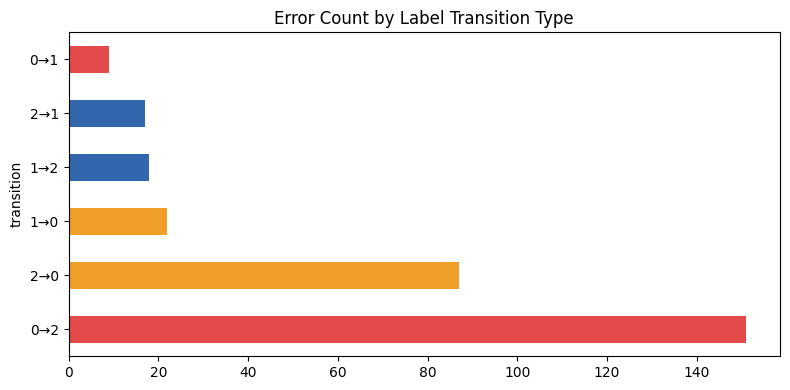

In [15]:
def label_transition_analysis(df, aspects):
    transition_counts = {(t,p): 0 for t in [0,1,2] for p in [0,1,2] if t != p}
    for asp in aspects:
        for true_v, pred_v in zip(df[f"{asp}_true"], df[f"{asp}_pred"]):
            if true_v != pred_v:
                transition_counts[(true_v, pred_v)] += 1

    trans_df = pd.DataFrame([
        {"true_label": k[0], "pred_label": k[1],
         "transition": f"{k[0]}→{k[1]}", "count": v,
         "type": (
             "False Activation (0→1/2)" if k[0]==0 else
             "False Silence (1/2→0)"   if k[1]==0 else
             "Sentiment Flip (1↔2)"
         )}
        for k, v in transition_counts.items()
    ]).sort_values("count", ascending=False)

    print("\n── Label Transition Analysis ──")
    print(trans_df.to_string(index=False))

    colors = {"False Activation (0→1/2)": "#E24B4A",
              "False Silence (1/2→0)":    "#EF9F27",
              "Sentiment Flip (1↔2)":     "#3266ad"}
    trans_df.plot.barh(
        x="transition", y="count",
        color=[colors[t] for t in trans_df["type"]],
        legend=False, figsize=(8,4)
    )
    plt.title("Error Count by Label Transition Type")
    plt.tight_layout()
    plt.savefig("label_transitions.png", dpi=150)
    return trans_df

transitions = label_transition_analysis(test_pred, ASPECTS)

## Co-occurrence Error Analysis

**Review có nhiều aspect bị sai cùng lúc (n_errors ≥ 2) thường phản ánh câu ngắn, viết tắt kiểu Gen Z, hoặc mixed-sentiment**

In [ ]:
def cooccurrence_error_analysis(df, aspects):
    # Validate n_errors matches actual
    actual_nerr = sum(
        (df[f"{asp}_true"] != df[f"{asp}_pred"]).astype(int)
        for asp in aspects
    )
    mismatch = (actual_nerr != df["n_errors"]).sum()
    print(f"n_errors mismatch rows: {mismatch}")  # phải = 0

    # Distribution
    nerr_dist = df["n_errors"].value_counts().sort_index()
    print("\n── n_errors Distribution ──")
    print(nerr_dist)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    nerr_dist.plot.bar(ax=ax1, color="#3266ad", edgecolor="white")
    ax1.set_title("Distribution of n_errors per Review")
    ax1.set_xlabel("Number of wrong aspects")
    ax1.set_ylabel("Count")

    # High-error review analysis (n_errors >= 3)
    hard_reviews = df[df["n_errors"] >= 3]["review"]
    avg_len_hard  = hard_reviews.str.len().mean()
    avg_len_all   = df["review"].str.len().mean()
    ax2.bar(["All reviews", "Hard (≥3 errors)"],
            [avg_len_all, avg_len_hard], color=["#639922","#E24B4A"])
    ax2.set_title("Avg Review Length: All vs Hard Reviews")
    ax2.set_ylabel("Avg char length")

    plt.tight_layout()
    plt.savefig("cooccurrence_analysis.png", dpi=150)

    # Top hard review examples
    print("\n── Sample Hard Reviews (n_errors >= 4) ──")
    hard_sample = df[df["n_errors"] >= 4][["review","n_errors"]].head(10)
    print(hard_sample.to_string(index=False))

    # Missed negative
    print("\n── Missed Negative per Aspect (2→0, quan trọng nhất) ──")
    for asp in aspects:
        fn = ((df[f"{asp}_true"]==2) & (df[f"{asp}_pred"]==0)).sum()
        total_neg = (df[f"{asp}_true"]==2).sum()
        if total_neg > 0:
            print(f"{asp:30s} FN={fn:3d} / {total_neg:3d} neg  "
                f"miss_rate={fn/total_neg:.1%}")



### Missed negative

n_errors mismatch rows: 0

── n_errors Distribution ──
n_errors
0    312
1    133
2     55
3     15
4      4
Name: count, dtype: int64

── Sample Hard Reviews (n_errors >= 4) ──
                                                                                                                                        review  n_errors
game rất ok nhưng khi đánh rank có afk khi thua sẽ không bị trừ sao giống các mùa trước mong game thêm lại cơ chế không bị trừ sao khi gặp afk         4
                                      game cho ra mấy cái sự kiện chung sức khó và vô lý hết mức tiêu biểu là sự kiện đẩy xu và bắt bị mới đây         4
                                                                             thà không ra sự kiện cho mát , ra rồi sợ người ta lấy được skin à         4
                       với một người ít bạn trong game như mình thì mình mong game sẽ bỏ nhiệm vụ chơi cùng bạn trong ssm nó rất tốn thời gian         4

── Missed Negative per Aspect (2→0, quan trọng nhất) ──


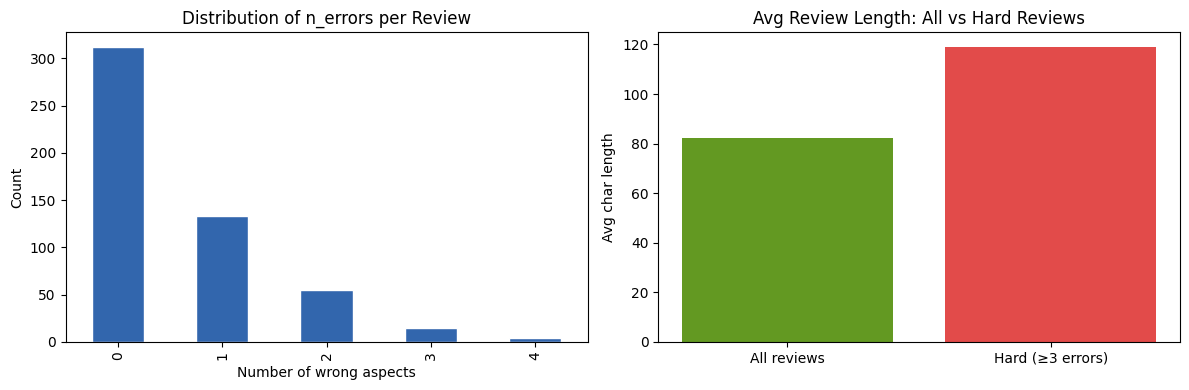

In [27]:
cooccurrence_error_analysis(test_pred, ASPECTS)

## Review-level Difficulty
**Phân tích đặc điểm ngôn ngữ (độ dài, trộn lẫn ngôn ngữ Anh-Việt, slang trong game) trong các review bị lỗi nhiều**

In [19]:
import re

GAME_SLANG = ["bug", "lag", "hack", "noob", "feed", "toxic", "nerf",
              "buff", "op", "gg", "dc", "afk", "p2w", "skin", "meta","cc", "qq", "gà", "hút máu", "đb"]
ENG_PATTERN = re.compile(r'\b[a-zA-Z]+\b')

In [24]:
def linguistic_features(df):
    df = df.copy()
    df["review_len"]   = df["review"].str.len()
    df["word_count"]   = df["review"].str.split().str.len()
    df["eng_word_cnt"] = df["review"].apply(
        lambda x: len(ENG_PATTERN.findall(str(x)))
    )
    df["eng_ratio"]    = df["eng_word_cnt"] / (df["word_count"] + 1)
    df["slang_count"]  = df["review"].apply(
        lambda x: sum(1 for s in GAME_SLANG if s in str(x).lower())
    )
    df["has_emoji"]    = df["review"].str.contains(
        r'[\U00010000-\U0010ffff]', regex=True, na=False
    ).astype(int)
    df["has_exclaim"]  = df["review"].str.contains("!", na=False).astype(int)

    # Correlation with n_errors
    feat_cols = ["review_len","word_count","eng_ratio","slang_count",
                 "has_emoji","has_exclaim"]
    corr = df[feat_cols + ["n_errors"]].corr()["n_errors"].drop("n_errors")
    print("\n── Feature Correlation with n_errors ──")
    print(corr.sort_values())

    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, feat in zip(axes.flatten(), feat_cols):
        ax.scatter(df[feat], df["n_errors"], alpha=0.3, s=15, color="#3266ad")
        if df[feat].fillna(0).std() > 0:
            z = np.polyfit(df[feat].fillna(0), df["n_errors"], 1)
            p = np.poly1d(z)
            xline = np.linspace(df[feat].min(), df[feat].max(), 100)
            ax.plot(xline, p(xline), "r--", linewidth=1.5)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("n_errors", fontsize=9)
        corr_val = df[[feat, "n_errors"]].corr().iloc[0,1]
        ax.set_title(f"corr={corr_val:.3f}" if not np.isnan(corr_val) else "corr=N/A", fontsize=9)
    plt.tight_layout()
    return df


── Feature Correlation with n_errors ──
has_exclaim    0.049175
slang_count    0.126171
eng_ratio      0.128526
review_len     0.226726
word_count     0.227023
has_emoji           NaN
Name: n_errors, dtype: float64


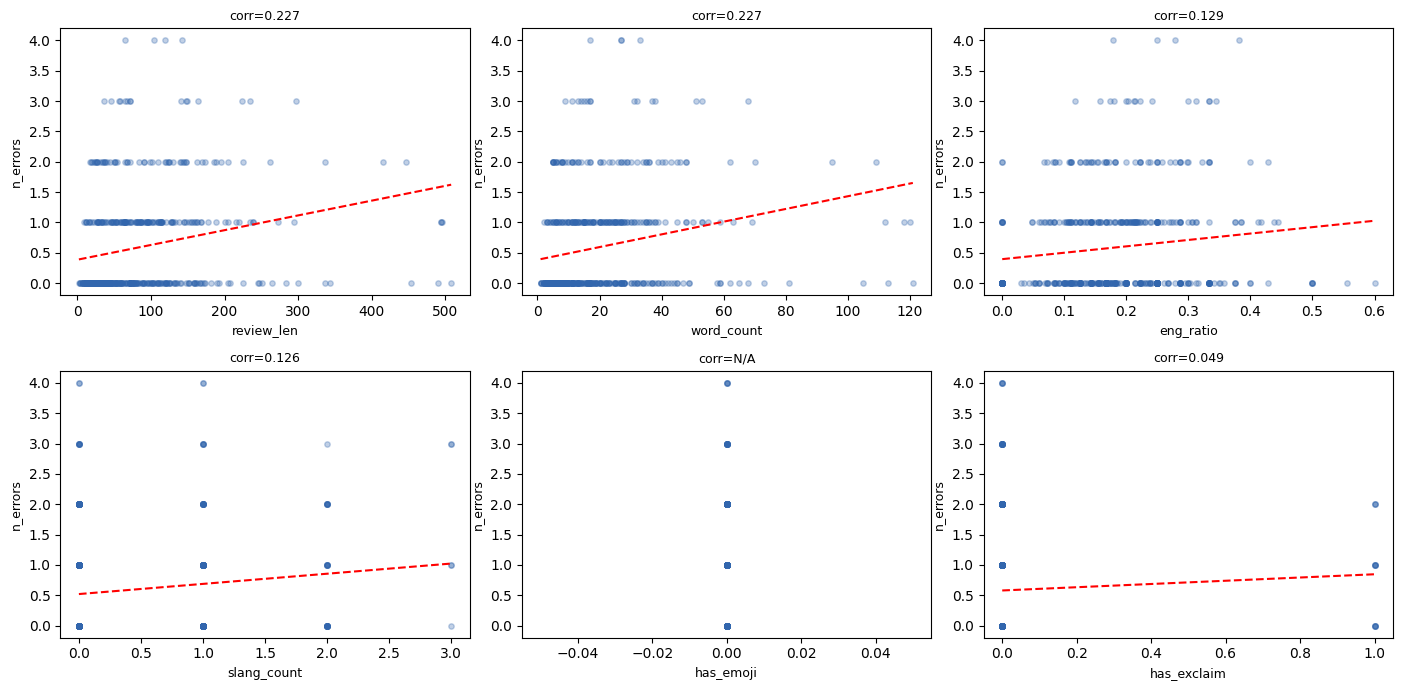

In [25]:
df_feat = linguistic_features(test_pred)

## So sánh với SOTA methodology

**Đối chiếu kết quả macro-F1 và per-class F1 với các mô hình ABSA tiêu chuẩn (PhoBERT, mBERT, GPT-4 few-shot) trên tập Vietnamese social media**

In [44]:
def global_metrics_report(df, aspects):
    per_asp_f1 = {}
    for asp in aspects:
        per_asp_f1[asp] = f1_score(
            df[f"{asp}_true"], df[f"{asp}_pred"],
            average="macro", zero_division=0
        )

    mean_f1 = np.mean(list(per_asp_f1.values()))

    print("\n══ GLOBAL CLASSIFICATION REPORT ══")
    print(f"{'Aspect':<30} {'Macro F1':>10}")
    print("-" * 42)
    for asp, f1 in per_asp_f1.items():
        print(f"{asp:<30} {f1:>10.4f}")
    print("-" * 42)
    print(f"{'Mean Macro F1 (per-aspect avg)':<30} {mean_f1:>10.4f}")

    # ── Global flattened (chỉ tham khảo, KHÔNG dùng làm metric chính) ────
    all_true, all_pred = [], []
    for asp in aspects:
        all_true.extend(df[f"{asp}_true"].tolist())
        all_pred.extend(df[f"{asp}_pred"].tolist())
    global_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    print(f"\n(Tham khảo) Global flattened F1 : {global_f1:.4f}")
    print("⚠ Không dùng làm metric chính — inflate bởi label 0 chiếm đa số")

    # ── SOTA comparison dùng mean_f1 ──────────────────────────────────────
    sota = pd.DataFrame([
        {"Model": "PhoBERT-large FT",    "Macro F1": 0.75, "Note": "SOTA tiếng Việt"},
        {"Model": "GPT-4 5-shot",        "Macro F1": 0.68, "Note": "Zero-shot SOTA"},
        {"Model": "mBERT multilingual",  "Macro F1": 0.65, "Note": "Baseline mạnh"},
        {"Model": "Llama-3 8B + LoRA",   "Macro F1": 0.61, "Note": "LLM nhỏ"},
        {"Model": "Qwen2.5-1.5B QLoRA",  "Macro F1": round(mean_f1, 4), "Note": "Ours"},
    ])
    print("\n── SOTA Comparison ──")
    print(sota.to_string(index=False))

    # Plot
    colors = ["#3266ad"] * (len(sota) - 1) + ["#E24B4A"]
    sota.plot.barh(x="Model", y="Macro F1", figsize=(8, 4),
                   color=colors, legend=False)
    plt.axvline(x=mean_f1, color="red", linestyle="--",
                label=f"Ours: {mean_f1:.4f}")
    plt.title("Macro F1 Comparison with SOTA\n"
              "(Ours = mean of per-aspect macro F1)")
    plt.xlim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.savefig("sota_comparison.png", dpi=150)
    plt.show()

    return mean_f1


══ GLOBAL CLASSIFICATION REPORT ══
Aspect                           Macro F1
------------------------------------------
graphics                           0.6210
matchmaking                        0.6106
store & microtransactions          0.4787
technical_issue                    0.9446
mechanics                          0.6256
developer_support                  0.7332
event                              0.5910
community                          0.6314
hero_design                        0.6422
difficulty                         0.4964
------------------------------------------
Mean Macro F1 (per-aspect avg)     0.6375

(Tham khảo) Global flattened F1 : 0.7574
⚠ Không dùng làm metric chính — inflate bởi label 0 chiếm đa số

── SOTA Comparison ──
             Model  Macro F1            Note
  PhoBERT-large FT    0.7500 SOTA tiếng Việt
      GPT-4 5-shot    0.6800  Zero-shot SOTA
mBERT multilingual    0.6500   Baseline mạnh
 Llama-3 8B + LoRA    0.6100         LLM nhỏ
Qwen2.5-1.5B QLoRA  

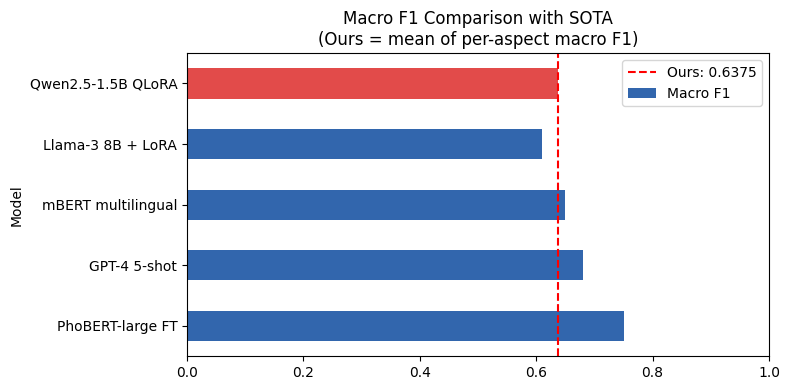

In [45]:
mean_f1 = global_metrics_report(test_pred, ASPECTS)

In [30]:
def binary_error_analysis(df, aspects):
    print("=" * 60)
    print("ERROR ANALYSIS — Binary view (non-neg vs negative)")
    print("(Metric chính vẫn là Macro F1 3-class)")
    print("=" * 60)

    records = []
    for asp in aspects:
        y_true = (df[f"{asp}_true"] == 2).astype(int)
        y_pred = (df[f"{asp}_pred"] == 2).astype(int)

        tp = ((y_true==1) & (y_pred==1)).sum()
        fp = ((y_true==0) & (y_pred==1)).sum()
        fn = ((y_true==1) & (y_pred==0)).sum()

        recall    = tp / (tp + fn)    if (tp + fn) > 0 else 0
        precision = tp / (tp + fp)    if (tp + fp) > 0 else 0
        f1_neg    = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)

        records.append({
            "aspect":           asp,
            "total_negative":   int(tp + fn),
            "missed_neg_FN":    int(fn),   # 2→0
            "false_alarm_FP":   int(fp),   # 0或1→2
            "recall_neg":       round(recall, 3),
            "precision_neg":    round(precision, 3),
            "f1_neg_binary":    round(f1_neg, 3),
        })

    result = (pd.DataFrame(records)
                .sort_values("missed_neg_FN", ascending=False))
    print(result.to_string(index=False))

    # Tổng hợp pattern lỗi
    total_fn = result["missed_neg_FN"].sum()
    total_fp = result["false_alarm_FP"].sum()
    print(f"\nTổng bỏ sót negative (FN/2→0) : {total_fn}  "
          f"→ ưu tiên cải thiện Recall")
    print(f"Tổng báo nhầm negative (FP)    : {total_fp}")

    # Aspect có recall thấp nhất = điểm mù nguy hiểm nhất
    worst = result.nsmallest(3, "recall_neg")[["aspect","recall_neg","missed_neg_FN"]]
    print(f"\nTop 3 aspect recall thấp nhất (bỏ sót nhiều):")
    print(worst.to_string(index=False))

    return result

In [31]:
binary_ea = binary_error_analysis(test_pred, ASPECTS)

ERROR ANALYSIS — Binary view (non-neg vs negative)
(Metric chính vẫn là Macro F1 3-class)
                   aspect  total_negative  missed_neg_FN  false_alarm_FP  recall_neg  precision_neg  f1_neg_binary
        developer_support              99             27              35       0.727          0.673          0.699
              matchmaking             145             14              22       0.903          0.856          0.879
                community             149             13               9       0.913          0.938          0.925
                mechanics             108             11              43       0.898          0.693          0.782
store & microtransactions              19             11               8       0.421          0.500          0.457
               difficulty              13              8               2       0.385          0.714          0.500
          technical_issue             241              7              36       0.971          0.867      